In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

import warnings
warnings.filterwarnings('ignore')

## Loan Defaulter

# Loan Defaulter Prediction with a Decision Tree

This notebook builds a supervised machine-learning model to predict whether a loan will be **Fully Paid** or **Charged Off**.

The workflow follows a production-style order:

1. Import libraries
2. Read and inspect the dataset
3. Perform exploratory data analysis (EDA)
4. Clean invalid values and handle missing data
5. Engineer useful features
6. Encode categorical features and scale numeric features
7. Split the data without target leakage
8. Train and evaluate a decision-tree classifier
9. Interpret the model with feature importance

The positive class is `Charged Off`, which represents a loan default. Because default prediction is a risk problem, precision, recall, F1-score, ROC-AUC, and the confusion matrix are more informative than accuracy alone.

* A CIBIL Score ranges from 300 to 900, with scores below 550–600 indicating a high risk of default. 
##  Credit Score Ranges & Default Risk

* 750–900 (Excellent): Lowest default risk; best card offers. 
* 650–749 (Good): Reasonable approval odds; moderate rates. 
* 550–649 (Fair): Higher default risk; strict terms. 
* 300–549 (Poor): Severe default risk; applications usually rejected. 

##  What Counts as a Default?

* Missed Payments: Failing to pay minimum dues for over 90 days triggers a formal default status. [6] 
* Score Drop: A single missed payment can instantly drop your score by 50 to 100 points. [7] 
* Report Duration: Formal defaults remain on your credit history file for up to 7 years, blocking new credit approvals. [6, 8] 




In [54]:
# Step 2: Read the credit-risk dataset
credit_url = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/credit_train.csv"
credit_df = pd.read_csv(credit_url)
df = credit_df.copy()
credit_df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


## Step 2: Read the Dataset

`credit_df` is the raw DataFrame loaded from the GitHub CSV. Keeping the raw data separate from later `clean_df` and `model_df` objects makes it easier to compare the original values with the modeling data.

In [11]:
# Basic data inspection
display(df.head())
display(df.tail())
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
99995,3f94c18c-ba8f-45d0-8610-88a684a410a9,2da51983-cfef-4b8f-a733-5dfaf69e9281,Fully Paid,147070,Short Term,725.0,475437.0,7 years,Own Home,other,2202.86,22.3,NaN,5,0,47766,658548.0,0.0,0.0
99996,06eba04f-58fc-424a-b666-ed72aa008900,77f2252a-b7d1-4b07-a746-1202a8304290,Fully Paid,99999999,Short Term,732.0,1289416.0,1 year,Rent,Debt Consolidation,13109.05,9.4,21.0,22,0,153045,509234.0,0.0,0.0
99997,e1cb4050-eff5-4bdb-a1b0-aabd3f7eaac7,2ced5f10-bd60-4a11-9134-cadce4e7b0a3,Fully Paid,103136,Short Term,742.0,1150545.0,6 years,Rent,Debt Consolidation,7315.57,18.8,18.0,12,1,109554,537548.0,1.0,0.0
99998,81ab928b-d1a5-4523-9a3c-271ebb01b4fb,3e45ffda-99fd-4cfc-b8b8-446f4a505f36,Fully Paid,530332,Short Term,746.0,1717524.0,9 years,Rent,Debt Consolidation,9890.07,15.0,NaN,8,0,404225,738254.0,0.0,0.0
99999,c63916c6-6d46-47a9-949a-51d09af4414f,1b3014be-5c07-4d41-abe7-44573c375886,Fully Paid,99999999,Short Term,743.0,935180.0,NaN,Own Home,Debt Consolidation,9118.10,13.0,NaN,4,1,45600,91014.0,1.0,0.0


Shape: (100000, 19)

Columns:
['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']


## Step 3: Data Manipulation and Initial Inspection

Initial inspection answers four questions:

- What is the size of the dataset?
- Which columns are available and what are their data types?
- Are there missing values?
- Are numeric distributions and categorical levels plausible?

This step is performed before changing the data so that cleaning decisions are evidence-based.

In [12]:
print('Missing values by column:')
display(df.isnull().sum())

print('Descriptive summary:')
display(df.describe(include='all').T)

Missing values by column:


Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                    19154
Annual Income                   19154
Years in current job             4222
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    53141
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 2
Bankruptcies                      204
Tax Liens                          10
dtype: int64

Descriptive summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan ID,100000,81999,14dd8831-6af5-400b-83ec-68e61888a048,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,100000,81999,981165ec-3274-42f5-a3b4-d104041a9ca9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan Status,100000,2,Fully Paid,77361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Loan Amount,100000.0,NaN,NaN,NaN,11760447.38946,31783942.546075,10802.0,179652.0,312246.0,524942.0,99999999.0
Term,100000,2,Short Term,72208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit Score,80846.0,NaN,NaN,NaN,1076.456089,1475.403791,585.0,705.0,724.0,741.0,7510.0
Annual Income,80846.0,NaN,NaN,NaN,1378276.559842,1081360.195662,76627.0,848844.0,1174162.0,1650663.0,165557393.0
Years in current job,95778,11,10+ years,31121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Home Ownership,100000,4,Home Mortgage,48410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purpose,100000,16,Debt Consolidation,78552,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Show the first five records that contain at least one missing value
missing_records = df[df.isnull().any(axis=1)]
missing_records.head(5)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0
5,89d8cb0c-e5c2-4f54-b056-48a645c543dd,4ffe99d3-7f2a-44db-afc1-40943f1f9750,Charged Off,206602,Short Term,7290.0,896857.0,10+ years,Home Mortgage,Debt Consolidation,16367.74,17.3,NaN,6,0,215308,272448.0,0.0,0.0


In [30]:
# show the % of missing records
credit_df.isnull().sum() / credit_df.shape[0] * 100

Loan ID                          0.000
Customer ID                      0.000
Loan Status                      0.000
Current Loan Amount              0.000
Term                             0.000
Credit Score                    19.154
Annual Income                   19.154
Years in current job             4.222
Home Ownership                   0.000
Purpose                          0.000
Monthly Debt                     0.000
Years of Credit History          0.000
Months since last delinquent    53.141
Number of Open Accounts          0.000
Number of Credit Problems        0.000
Current Credit Balance           0.000
Maximum Open Credit              0.002
Bankruptcies                     0.204
Tax Liens                        0.010
dtype: float64

In [31]:
# show descriptive summary of sample data
credit_df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+05,80846.000000,8.084600e+04,100000.000000,100000.000000,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000
mean,1.176045e+07,1076.456089,1.378277e+06,18472.412336,18.199141,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313
std,3.178394e+07,1475.403791,1.081360e+06,12174.992609,7.015324,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,10214.162500,13.500000,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,16220.300000,16.900000,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,24012.057500,21.700000,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


## Handling Missing values

In [32]:
# Replace Missing delinquent values by 0 ; assuming people have not delinquent in past
credit_df['Months since last delinquent'] = credit_df['Months since last delinquent'].fillna(0)

In [33]:
credit_df['Credit Score'].unique()

array([ 709.,   nan,  741.,  721., 7290.,  730.,  678.,  739.,  728.,
        740.,  743.,  727.,  723.,  747.,  687.,  750.,  714.,  724.,
        704.,  688.,  749.,  746.,  737.,  729.,  733.,  725.,  745.,
        720.,  718.,  682., 7120.,  680.,  710.,  598.,  719., 6610.,
        652.,  736., 7380.,  644.,  672., 7370.,  699.,  751.,  694.,
        675.,  657.,  748.,  666.,  734.,  742.,  705.,  731., 6240.,
        712.,  685.,  717.,  722.,  618.,  676.,  692., 7210.,  732.,
        649.,  695.,  744.,  686.,  637.,  697.,  706.,  715.,  707.,
        726.,  738., 7500.,  716., 7020.,  651.,  708.,  698.,  689.,
        735.,  703.,  693., 7080.,  645.,  691.,  673.,  700., 7140.,
        658.,  674.,  654., 7490.,  681.,  696.,  713.,  668., 7360.,
        659., 7160.,  647.,  683.,  670.,  623.,  711.,  639.,  671.,
       6990.,  614.,  667.,  701., 7410., 7310., 7040., 7060.,  615.,
       7200.,  656.,  653.,  664.,  613., 7450., 7300.,  636.,  702.,
       7430.,  594.,

In [34]:
credit_df['Credit Score'] = credit_df[credit_df['Credit Score'] >= 900]['Credit Score'] / 10

In [35]:
credit_df['Credit Score'].unique()

array([ nan, 729., 712., 661., 738., 737., 624., 721., 750., 702., 708.,
       714., 749., 736., 716., 699., 741., 731., 704., 706., 720., 745.,
       730., 743., 717., 700., 728., 709., 697., 746., 692., 735., 719.,
       669., 675., 701., 653., 727., 742., 681., 707., 739., 747., 667.,
       671., 658., 694., 680., 711., 713., 586., 696., 715., 640., 683.,
       636., 665., 674., 726., 748., 698., 725., 732., 718., 664., 678.,
       609., 724., 655., 690., 659., 684., 666., 740., 676., 734., 686.,
       687., 668., 722., 646., 650., 688., 654., 610., 733., 751., 693.,
       643., 616., 703., 663., 723., 689., 682., 685., 710., 621., 615.,
       744., 608., 620., 657., 611., 656., 673., 641., 631., 596., 635.,
       647., 652., 670., 695., 672., 629., 677., 648., 638., 705., 639.,
       691., 662., 637., 660., 625., 645., 601., 649., 651., 585., 630.,
       679., 633., 613., 622., 644., 634., 627., 626., 617., 594., 595.,
       642., 618., 590., 632., 623., 612., 628., 59

In [36]:
#
credit_df['Credit Score'] = credit_df['Credit Score'].fillna(round(credit_df['Credit Score'].mean()))

In [37]:
credit_df['Annual Income'] = credit_df['Annual Income'].fillna(round(credit_df['Annual Income'].mean()))

In [38]:
credit_df['Years in current job'].unique()

<StringArray>
[  '8 years', '10+ years',   '3 years',   '5 years',  '< 1 year',   '2 years',
   '4 years',   '9 years',   '7 years',    '1 year',         nan,   '6 years']
Length: 12, dtype: str

In [39]:
credit_df['Years in current job'] = credit_df['Years in current job'].str.replace(' years', '').str.replace(' year', '').str.replace('< 1', '0.5').str.replace('+', '')

In [40]:
credit_df['Years in current job'].unique()

<StringArray>
['8', '10', '3', '5', '0.5', '2', '4', '9', '7', '1', nan, '6']
Length: 12, dtype: str

In [41]:
credit_df['Years in current job'] = credit_df['Years in current job'].astype('float')

In [42]:
credit_df.fillna({'Years in current job': credit_df['Years in current job'].median()}, inplace = True)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,711.0,1167493.0,8.0,Home Mortgage,Home Improvements,5214.74,17.2,0.0,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,711.0,1378277.0,10.0,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,711.0,2231892.0,8.0,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,711.0,806949.0,3.0,Own Home,Debt Consolidation,8741.90,12.0,0.0,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,711.0,1378277.0,5.0,Rent,Debt Consolidation,20639.70,6.1,0.0,15,0,253460,427174.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3f94c18c-ba8f-45d0-8610-88a684a410a9,2da51983-cfef-4b8f-a733-5dfaf69e9281,Fully Paid,147070,Short Term,711.0,475437.0,7.0,Own Home,other,2202.86,22.3,0.0,5,0,47766,658548.0,0.0,0.0
99996,06eba04f-58fc-424a-b666-ed72aa008900,77f2252a-b7d1-4b07-a746-1202a8304290,Fully Paid,99999999,Short Term,711.0,1289416.0,1.0,Rent,Debt Consolidation,13109.05,9.4,21.0,22,0,153045,509234.0,0.0,0.0
99997,e1cb4050-eff5-4bdb-a1b0-aabd3f7eaac7,2ced5f10-bd60-4a11-9134-cadce4e7b0a3,Fully Paid,103136,Short Term,711.0,1150545.0,6.0,Rent,Debt Consolidation,7315.57,18.8,18.0,12,1,109554,537548.0,1.0,0.0
99998,81ab928b-d1a5-4523-9a3c-271ebb01b4fb,3e45ffda-99fd-4cfc-b8b8-446f4a505f36,Fully Paid,530332,Short Term,711.0,1717524.0,9.0,Rent,Debt Consolidation,9890.07,15.0,0.0,8,0,404225,738254.0,0.0,0.0


In [43]:
credit_df.isnull().sum()

Loan ID                           0
Customer ID                       0
Loan Status                       0
Current Loan Amount               0
Term                              0
Credit Score                      0
Annual Income                     0
Years in current job              0
Home Ownership                    0
Purpose                           0
Monthly Debt                      0
Years of Credit History           0
Months since last delinquent      0
Number of Open Accounts           0
Number of Credit Problems         0
Current Credit Balance            0
Maximum Open Credit               2
Bankruptcies                    204
Tax Liens                        10
dtype: int64

In [44]:
credit_df.dropna(inplace = True)

In [46]:
credit_df.shape

(99794, 19)

## * 5.  Drop Columns - Loan ID and Customer ID.....which are unnecessary

In [47]:
credit_df.drop(['Loan ID', 'Customer ID'], axis =1,inplace= True)

In [48]:
credit_df['Loan Status'].unique()

<StringArray>
['Fully Paid', 'Charged Off']
Length: 2, dtype: str

In [50]:
credit_df.info()

<class 'pandas.DataFrame'>
Index: 99794 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan Status                   99794 non-null  str    
 1   Current Loan Amount           99794 non-null  int64  
 2   Term                          99794 non-null  str    
 3   Credit Score                  99794 non-null  float64
 4   Annual Income                 99794 non-null  float64
 5   Years in current job          99794 non-null  float64
 6   Home Ownership                99794 non-null  str    
 7   Purpose                       99794 non-null  str    
 8   Monthly Debt                  99794 non-null  float64
 9   Years of Credit History       99794 non-null  float64
 10  Months since last delinquent  99794 non-null  float64
 11  Number of Open Accounts       99794 non-null  int64  
 12  Number of Credit Problems     99794 non-null  int64  
 13  Current Credit Ba

In [49]:
credit_df.columns

Index(['Loan Status', 'Current Loan Amount', 'Term', 'Credit Score',
       'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose',
       'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='str')

## 6 Apply Data Preprocessing - Handling all categorical values by Label Encoder

In [52]:
credit_df['Loan Status'].unique()

<StringArray>
['Fully Paid', 'Charged Off']
Length: 2, dtype: str

In [63]:
from sklearn.preprocessing import LabelEncoder

# Detect all categorical columns
categorical_columns = credit_df.select_dtypes(include='object').columns.tolist()

# Store encoders for future prediction
label_encoders = {}

for column in categorical_columns:
    # Fill missing categorical values with the mode
    credit_df[column] = credit_df[column].fillna(
        credit_df[column].mode()[0]
    ).astype(str)

    # Apply LabelEncoder
    encoder = LabelEncoder()
    credit_df[column] = encoder.fit_transform(credit_df[column])

    # Save encoder and display mapping
    label_encoders[column] = encoder

    print(f'\n{column} encoding:')
    print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

print('Categorical columns encoded:')
print(categorical_columns)

display(credit_df.head())


Loan ID encoding:
{'0000757f-a121-41ed-b17b-162e76647c1f': np.int64(0), '0000afa6-8902-4f8f-b870-25a8fdad0aeb': np.int64(1), '00020fb0-6b8a-4b3a-8c72-9c4c847e8cb6': np.int64(2), '00045ecd-59e9-4752-ba0d-679ff71692b3': np.int64(3), '0004f37b-5859-40f6-98d0-367aa3b3f3f1': np.int64(4), '00053198-2da4-438f-9c77-5dac5a31703a': np.int64(5), '000582b2-2b2e-4290-9360-43e3a93b57c2': np.int64(6), '00069ff1-a877-4d35-81be-7cd359b99956': np.int64(7), '0006dbc6-15b5-4223-8f2a-5e3498fbf9a9': np.int64(8), '0008255a-402e-4716-9e0a-8bdf55309781': np.int64(9), '0008cacc-1ea9-4599-b114-12709b13c85d': np.int64(10), '000a0abe-b839-414d-9b00-8ba33b47ebce': np.int64(11), '000a4e53-0c08-4fce-a0c2-f634c3b77013': np.int64(12), '000bc65a-6a7c-4566-86f3-203b4ec35eca': np.int64(13), '000bc9de-0b39-4e53-ba71-222ec0fd2dc9': np.int64(14), '000bce36-32bf-4cea-a625-8e7ee9175383': np.int64(15), '000c0c27-1961-4336-b760-a300e1bce9b0': np.int64(16), '000c16df-c24f-41cf-a90e-60301d131bb9': np.int64(17), '000dada0-f2a3-4d6

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,6697,48724,1,445412,1,709.0,1167493.0,8,1,5,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,23041,14688,1,262328,1,NaN,NaN,1,1,3,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,25441,30541,1,99999999,1,741.0,2231892.0,8,2,3,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,38341,74173,1,347666,0,721.0,806949.0,3,2,3,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,68058,41470,1,176220,1,NaN,NaN,5,3,3,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


In [7]:
# Handle missing values
# Use the median for numeric columns because it is less affected by outliers.
numeric_columns = df.select_dtypes(include='number').columns
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Use the most frequent value for categorical columns.
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

print('Missing values after imputation:')
display(df.isnull().sum())

Missing values after imputation:


Loan ID                         0
Customer ID                     0
Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Annual Income                   0
Years in current job            0
Home Ownership                  0
Purpose                         0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
dtype: int64

In [29]:
credit_df['Credit Score'].unique()

array([ 709.,   nan,  741.,  721., 7290.,  730.,  678.,  739.,  728.,
        740.,  743.,  727.,  723.,  747.,  687.,  750.,  714.,  724.,
        704.,  688.,  749.,  746.,  737.,  729.,  733.,  725.,  745.,
        720.,  718.,  682., 7120.,  680.,  710.,  598.,  719., 6610.,
        652.,  736., 7380.,  644.,  672., 7370.,  699.,  751.,  694.,
        675.,  657.,  748.,  666.,  734.,  742.,  705.,  731., 6240.,
        712.,  685.,  717.,  722.,  618.,  676.,  692., 7210.,  732.,
        649.,  695.,  744.,  686.,  637.,  697.,  706.,  715.,  707.,
        726.,  738., 7500.,  716., 7020.,  651.,  708.,  698.,  689.,
        735.,  703.,  693., 7080.,  645.,  691.,  673.,  700., 7140.,
        658.,  674.,  654., 7490.,  681.,  696.,  713.,  668., 7360.,
        659., 7160.,  647.,  683.,  670.,  623.,  711.,  639.,  671.,
       6990.,  614.,  667.,  701., 7410., 7310., 7040., 7060.,  615.,
       7200.,  656.,  653.,  664.,  613., 7450., 7300.,  636.,  702.,
       7430.,  594.,

In [13]:
# Step 5: Exploratory data analysis (EDA)
# The target is Loan Status: Fully Paid versus Charged Off.
print('Dataset shape:', credit_df.shape)
print('\nTarget distribution:')
display(credit_df['Loan Status'].value_counts())
print('\nTarget distribution (%):')
display((credit_df['Loan Status'].value_counts(normalize=True) * 100).round(2))
print('\nData types:')
display(credit_df.dtypes)

Dataset shape: (100000, 19)

Target distribution:


Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64


Target distribution (%):


Loan Status
Fully Paid     77.36
Charged Off    22.64
Name: proportion, dtype: float64


Data types:


Loan ID                             str
Customer ID                         str
Loan Status                         str
Current Loan Amount               int64
Term                                str
Credit Score                    float64
Annual Income                   float64
Years in current job                str
Home Ownership                      str
Purpose                             str
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts           int64
Number of Credit Problems         int64
Current Credit Balance            int64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

## Step 5: Exploratory Data Analysis

EDA is used to understand the target balance, identify relationships between credit characteristics and loan outcomes, and detect unusual values. The plots below focus on loan status, term, credit score, annual income, and correlations among numeric variables.

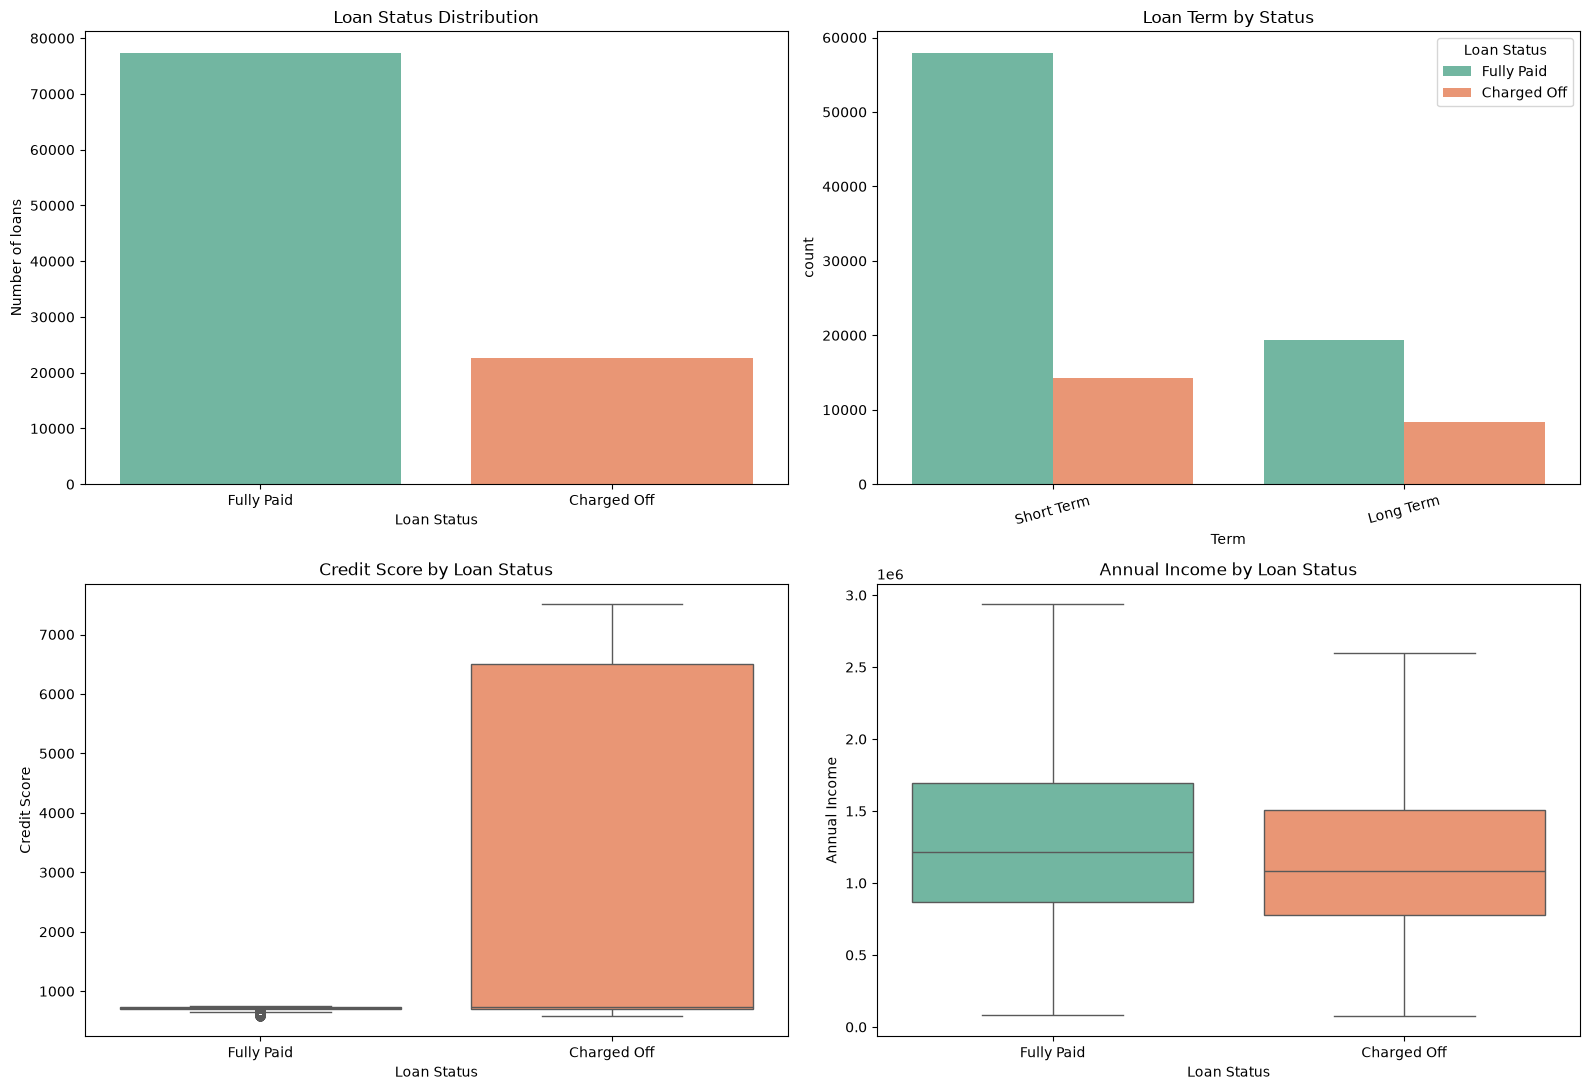

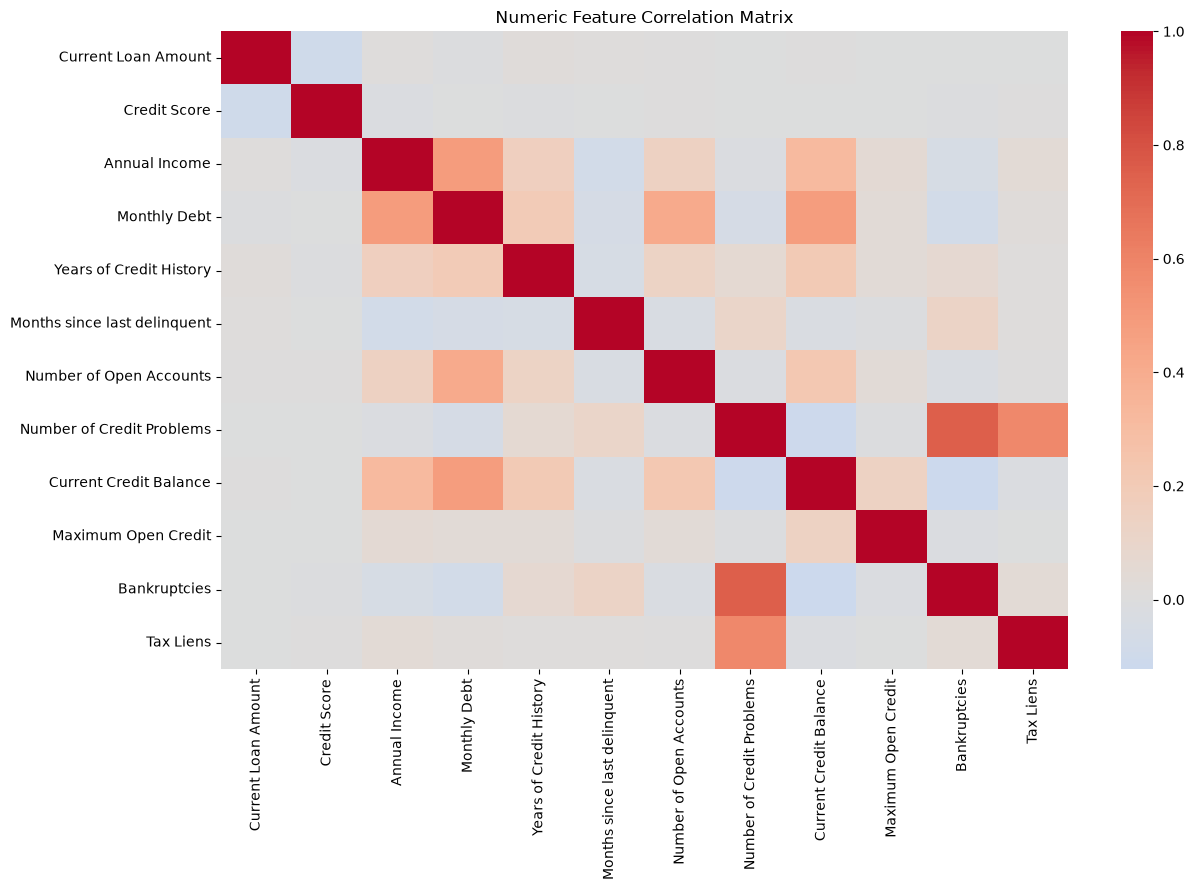

In [14]:
# EDA plots: target, categorical variables, and important numeric variables
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=credit_df, x='Loan Status', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Loan Status Distribution')
axes[0, 0].set_xlabel('Loan Status')
axes[0, 0].set_ylabel('Number of loans')

sns.countplot(data=credit_df, x='Term', hue='Loan Status', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Loan Term by Status')
axes[0, 1].tick_params(axis='x', rotation=15)

sns.boxplot(data=credit_df, x='Loan Status', y='Credit Score', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Credit Score by Loan Status')

sns.boxplot(data=credit_df, x='Loan Status', y='Annual Income', ax=axes[1, 1], palette='Set2', showfliers=False)
axes[1, 1].set_title('Annual Income by Loan Status')

plt.tight_layout()
plt.show()

numeric_columns_for_corr = credit_df.select_dtypes(include='number').columns
plt.figure(figsize=(13, 9))
sns.heatmap(credit_df[numeric_columns_for_corr].corr(), cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [55]:
# Step 6: Data cleaning
# The source contains sentinel and impossible values that should be treated as missing.
clean_df = credit_df.copy()

# 99,999,999 is used as a missing-value sentinel in Current Loan Amount.
clean_df['Current Loan Amount'] = clean_df['Current Loan Amount'].replace(99999999, np.nan)

# A normal credit score is between 300 and 850; invalid values are treated as missing.
clean_df.loc[~clean_df['Credit Score'].between(300, 850), 'Credit Score'] = np.nan

# Remove non-positive and billion-scale Maximum Open Credit outliers.
clean_df.loc[
    (clean_df['Maximum Open Credit'] <= 0) |
    (clean_df['Maximum Open Credit'] > 10_000_000),
    'Maximum Open Credit'
] = np.nan

print('Missing values after source-value cleaning:')
display(clean_df.isnull().sum().sort_values(ascending=False).head(10))

Missing values after source-value cleaning:


Months since last delinquent    53141
Credit Score                    23705
Annual Income                   19154
Current Loan Amount             11484
Years in current job             4222
Maximum Open Credit               931
Bankruptcies                      204
Tax Liens                          10
Loan Status                         0
Loan ID                             0
dtype: int64

## Step 6: Data Cleaning

Missing values and invalid sentinel values must be handled before training. A sentinel is a numeric code that means “unknown” but looks like a real measurement. We convert known sentinel or impossible values to `NaN`; the modeling pipeline then imputes them using statistics learned from the training data only.

In [56]:
# Step 7: Feature engineering
# Convert years in current job to an ordered numeric feature.
job_year_map = {
    '< 1 year': 0.5,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}
clean_df['Job Years'] = clean_df['Years in current job'].map(job_year_map)
clean_df = clean_df.drop(columns=['Years in current job'])

# Debt-to-income proxy: monthly debt relative to annual income.
clean_df['Debt to Annual Income'] = (clean_df['Monthly Debt'] * 12) / clean_df['Annual Income']

# Remove identifiers because they identify records rather than describe credit risk.
clean_df = clean_df.drop(columns=['Loan ID', 'Customer ID'])

print('Engineered columns:')
print(clean_df.columns.tolist())
display(clean_df.head())

Engineered columns:
['Loan Status', 'Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens', 'Job Years', 'Debt to Annual Income']


,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Job Years,Debt to Annual Income
0,Fully Paid,445412.0,Short Term,709.0,1167493.0,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0,8.0,0.053599
1,Fully Paid,262328.0,Short Term,NaN,NaN,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0,10.0,NaN
2,Fully Paid,NaN,Short Term,741.0,2231892.0,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0,8.0,0.157000
3,Fully Paid,347666.0,Long Term,721.0,806949.0,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0,3.0,0.129999
4,Fully Paid,176220.0,Short Term,NaN,NaN,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0,5.0,NaN


## Step 7: Feature Engineering

Feature engineering converts raw fields into features that better represent the credit decision. Here, employment duration is converted from text to numeric years, a debt-to-annual-income proxy is created, and identifier columns are removed because they do not describe repayment behavior.

In [57]:
# Step 8: Define the target and split the data
# Charged Off is the positive class: the loan defaulted.
model_df = clean_df.copy()
model_df['Loan Status'] = model_df['Loan Status'].map({'Fully Paid': 0, 'Charged Off': 1})
model_df = model_df.dropna(subset=['Loan Status'])

X = model_df.drop(columns='Loan Status')
y = model_df['Loan Status'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('\nTraining target distribution:')
display(y_train.value_counts(normalize=True).rename({0: 'Fully Paid', 1: 'Charged Off'}))

Training shape: (80000, 17)
Testing shape: (20000, 17)

Training target distribution:


Loan Status
Fully Paid     0.773613
Charged Off    0.226387
Name: proportion, dtype: float64

In [58]:
# Step 9: Label encode categorical features and scale all features
# Fit each LabelEncoder on training values only to avoid data leakage.
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()
label_encoders = {}

for column in categorical_features:
    train_mode = X_train_encoded[column].mode()[0]
    X_train_encoded[column] = X_train_encoded[column].fillna(train_mode).astype(str)
    X_test_encoded[column] = X_test_encoded[column].fillna(train_mode).astype(str)

    encoder = LabelEncoder()
    X_train_encoded[column] = encoder.fit_transform(X_train_encoded[column])
    category_map = {category: index for index, category in enumerate(encoder.classes_)}
    X_test_encoded[column] = X_test_encoded[column].map(category_map).fillna(-1).astype(int)
    label_encoders[column] = encoder

# Impute numeric values and scale the complete encoded feature matrix.
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print('Label-encoded categorical features:', categorical_features)
print('Total model features:', X_train_encoded.shape[1])

Label-encoded categorical features: ['Term', 'Home Ownership', 'Purpose']
Total model features: 17


## Step 9: Label Encoding and Feature Scaling

`LabelEncoder` assigns an integer label to each category in every categorical feature. Each encoder is fitted on the training data only; if a category appears only in the test data, it receives `-1`. Missing categorical values are filled with the training mode before encoding. `StandardScaler` then standardizes the complete numeric matrix.

In [59]:
# Step 10: Train a decision-tree classifier
# class_weight='balanced' gives more importance to the minority default class.
decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42
    ))
])

decision_tree_model.fit(X_train_encoded, y_train)
y_pred = decision_tree_model.predict(X_test_encoded)
y_probability = decision_tree_model.predict_proba(X_test_encoded)[:, 1]

print('Decision-tree model trained successfully.')

Decision-tree model trained successfully.


## Step 10: Decision-Tree Modeling

A decision tree learns a sequence of if/then rules that separates paid and defaulted loans. Limiting `max_depth` and requiring a minimum number of samples per leaf controls overfitting. `class_weight='balanced'` compensates for the unequal number of paid and charged-off loans.

Accuracy: 0.6663
ROC-AUC: 0.7414

Classification report:
              precision    recall  f1-score   support

  Fully Paid       0.87      0.67      0.76     15472
 Charged Off       0.37      0.65      0.47      4528

    accuracy                           0.67     20000
   macro avg       0.62      0.66      0.61     20000
weighted avg       0.75      0.67      0.69     20000



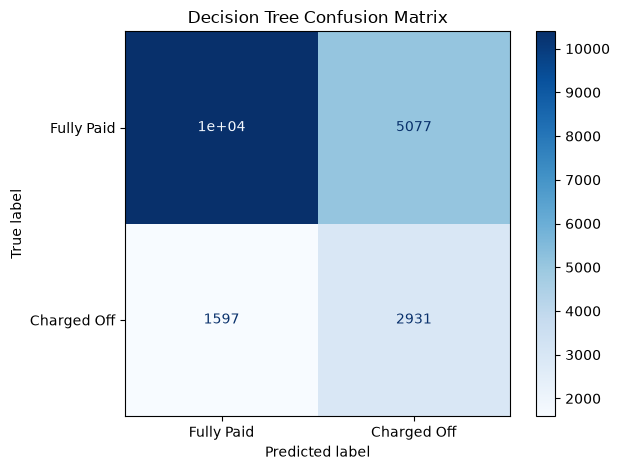

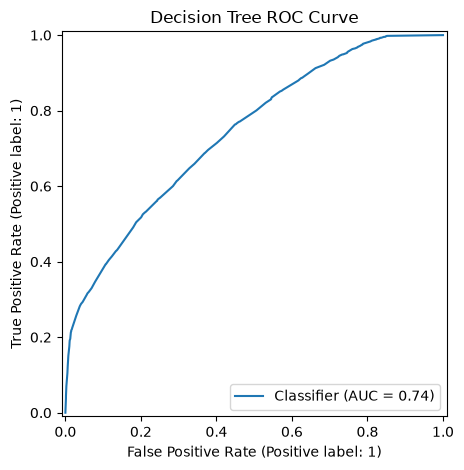

In [60]:
# Step 11: Evaluate the model
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, y_probability), 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fully Paid', 'Charged Off']).plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_probability)
plt.title('Decision Tree ROC Curve')
plt.tight_layout()
plt.show()

## Step 11: Model Evaluation

For default detection, recall for `Charged Off` measures how many actual defaults were found. Precision measures how many predicted defaults were truly defaults. ROC-AUC evaluates ranking quality across classification thresholds. The confusion matrix shows the four types of prediction outcomes.

,Feature,Importance
2,Credit Score,4.346968e-01
0,Current Loan Amount,2.569813e-01
16,Debt to Annual Income,1.761031e-01
3,Annual Income,5.156589e-02
1,Term,3.278483e-02
12,Maximum Open Credit,1.430318e-02
4,Home Ownership,6.577100e-03
7,Years of Credit History,6.493938e-03
6,Monthly Debt,5.966993e-03
11,Current Credit Balance,5.786603e-03


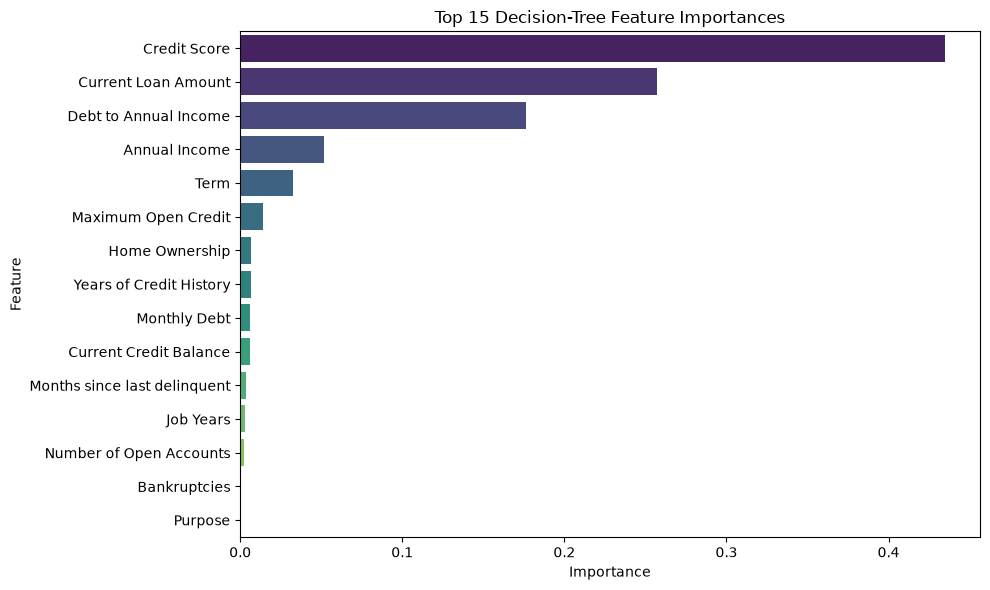

In [61]:
# Step 12: Inspect the most important model features
feature_names = decision_tree_model.named_steps['preprocessor'].get_feature_names_out()
feature_importances = decision_tree_model.named_steps['classifier'].feature_importances_

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    .sort_values('Importance', ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Decision-Tree Feature Importances')
plt.tight_layout()
plt.show()